# Getting started with the WCC ETC

The Widefield Context Camera (WCC) Exposure Time Calculator (ETC) estimates the
signal-to-noise ratio (SNR) a source will reach in a given exposure. The workflow is
always the same three steps:

1. **Build a scene** — the astrophysical source plus its background (`get_scene`).
2. **Build a simulation** for a sensor + filter combination
   (`Simulation.from_sensor_and_scene`).
3. **Ask it questions** — SNR for a time, required time for an SNR, peak pixel /
   saturation, and more.

This notebook walks through that core loop. The other notebooks in this directory go
deeper on individual features (PSF-aware SNR, defocus, `n_reads`, parametric spectra,
saturation) — see **Where to go next** at the end.


## Imports

We set the matplotlib fonts to match the rest of the notebooks.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import wcc_etc
wcc_etc.set_wcc_style()

## 1. Build a scene

`get_scene` returns the thing you want to observe together with its background. Here we use
a Sun-like **G5V** star at **r = 20 mag** on a **zodiacal** background (itself specified by a
bandpass and a surface-brightness magnitude). `host=None` means there is no host galaxy /
extended component.

The `name` can be a spectral type (`'G5V'`, `'K3IV'`, ...) or a parametric spectrum
(`'blackbody'`, `'flat'`, `'powerlaw'`, `'emission'`) — see `06_source_spectra.ipynb`.

In [2]:
scene = wcc_etc.get_scene(name='G5V',
                          mag=20,
                          host=None,
                          background='zodi',
                          bandpass='johnson_r',
                          background_prop={'bandpass': 'johnson_r', 'mag': 22.5})

print('source     :', scene.source.meta['spectrum'], 'at r =', scene.source.mag)
print('background : zodi, johnson_r =', scene.background.mag, '/ arcsec^2')

source     : G5V at r = 20.0 mag(AB)
background : zodi, johnson_r = 22.5 mag(AB) / arcsec^2


## 2. Build a simulation for a sensor + filter

`Simulation.from_sensor_and_scene` pairs the scene with a detector + filter, given as a
`kind:band` label (e.g. `'sony:r'`, `'sony:bb'`, `'qcmos:r'`). The simulation reads the
sensor's pixel size, gain, read noise, dark current, and the filter throughput from the
bundled config files.

In [3]:
sensor_and_filter = 'sony:r'
simu = wcc_etc.Simulation.from_sensor_and_scene(sensor_and_filter, scene)

print('filter      :', sensor_and_filter)
print('pixel size  :', simu.meta['sensor']['pixel_size'])
print('bit depth   :', simu.meta['sensor']['bit_depth'], 'bit')

filter      : sony:r
pixel size  : 3.76
bit depth   : 16 bit


## 3. Compute the SNR

`get_snr(time)` runs the 2-D image simulation and returns a dict; `["snr"]` is the
signal-to-noise ratio. The time can be a scalar or an array — it broadcasts — so a
single call gives you an SNR-vs-time curve.

[wcc_etc] note: even n_pixels is rounded up by 1 to center the PSF peak (shown once).


SNR at 60 s : 136.2


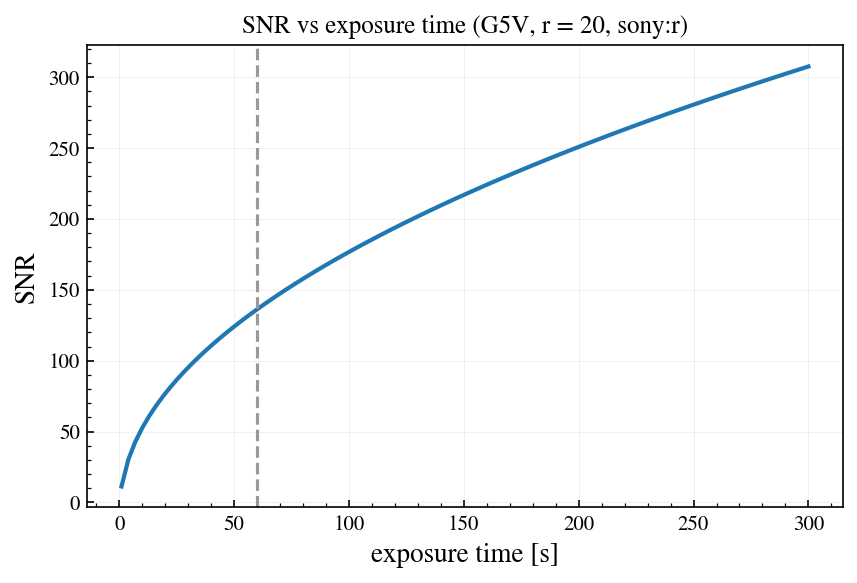

In [4]:
# single exposure time
snr_60 = simu.get_snr(time=60)["snr"]
print(f'SNR at 60 s : {float(snr_60):.1f}')

# an array of times broadcasts
times = np.linspace(1, 300, 100)
snr_curve = simu.get_snr(time=times)["snr"]

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(times, snr_curve, lw=2)
ax.axvline(60, ls='--', color='0.6')
ax.set_xlabel('exposure time [s]')
ax.set_ylabel('SNR')
ax.set_title('SNR vs exposure time (G5V, r = 20, sony:r)')
plt.show()

## 4. Inspect and update parameters

Every tunable parameter is listed in `simu.mutable_parameters`, and the current values live
in `simu.meta`. Use `simu.update(**kwargs)` to change them in place (double-underscore picks
out nested fields, e.g. `source__mag`), then recompute.

In [5]:
print('some mutable parameters:')
print('  ', simu.mutable_parameters[:10], '...')

snr_before = float(simu.get_snr(60)["snr"])

# make the source 2 mag brighter and add some pointing jitter
simu.update(source__mag=18, jitter_sigma=10)

snr_after = float(simu.get_snr(60)["snr"])
print(f'\nSNR @60 s  before (r=20)         : {snr_before:.1f}')
print(f'SNR @60 s  after  (r=18, jitter) : {snr_after:.1f}')
assert snr_after > snr_before  # brighter source -> higher SNR

some mutable parameters:
   ['time', 'r_aper_mas', 'n_reads', 'telescope__f_num', 'telescope__diameter_primary', 'telescope__jitter_sigma', 'sensor__bandpass', 'sensor__bandpass_name', 'sensor__pixel_size', 'sensor__read_noise'] ...



SNR @60 s  before (r=20)         : 136.2
SNR @60 s  after  (r=18, jitter) : 346.0


## 5. Visualize the source spectrum and filter bandpass

The scene and sensor objects know how to plot themselves, which is handy for a quick sanity
check that you set up the source and filter you intended.

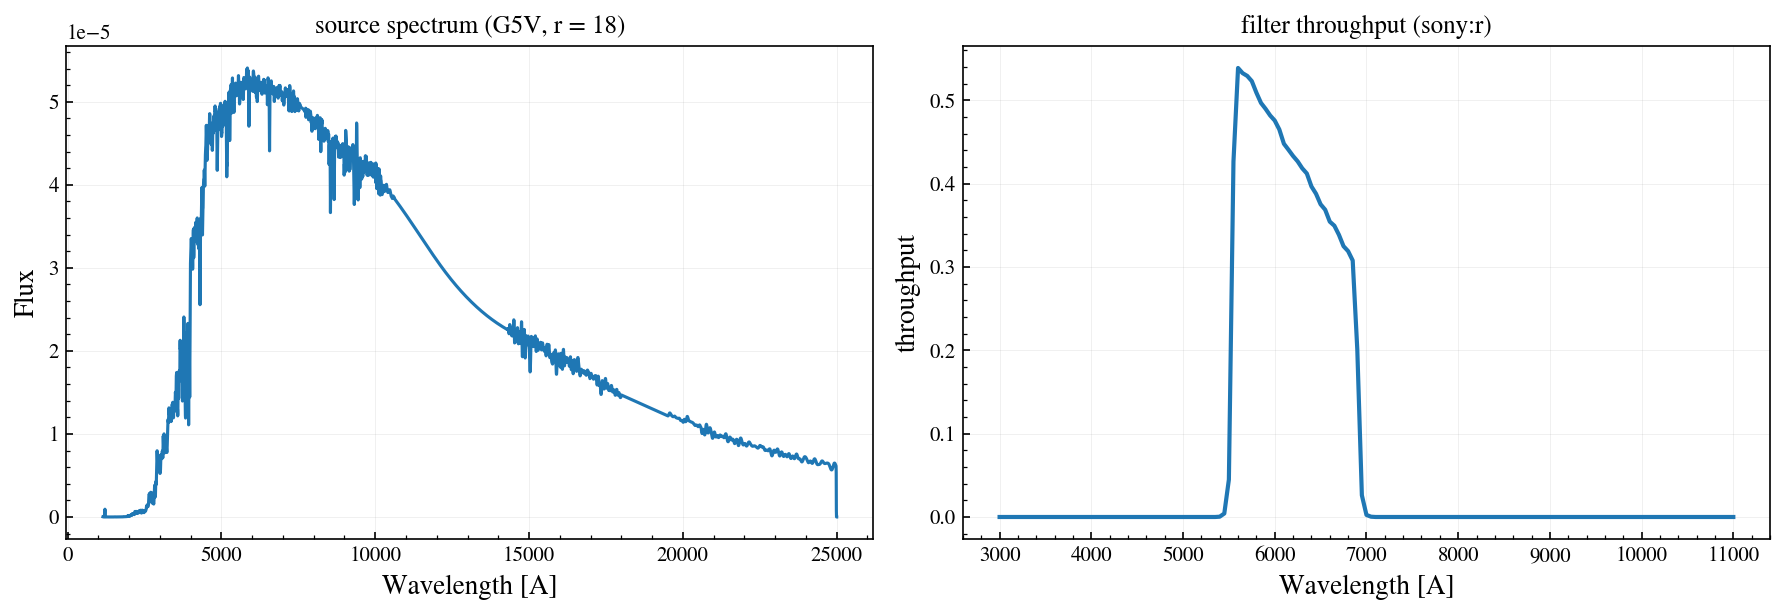

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

# source spectrum (the SceneElement plots itself onto a given axes)
simu.scene.source.show(ax=axes[0])
axes[0].set_title('source spectrum (G5V, r = 18)')

# filter bandpass / throughput (synphot SpectralElement -> plot its arrays)
bp = simu.sensor.bandpass
wave = bp.waveset
axes[1].plot(wave.to('Angstrom').value, bp(wave).value, lw=2)
axes[1].set_xlabel('Wavelength [A]')
axes[1].set_ylabel('throughput')
axes[1].set_title('filter throughput (sony:r)')

plt.tight_layout()
plt.show()

## Where to go next

| Notebook | What it adds |
|---|---|
| `02_saturation_flag.ipynb` | Peak-pixel value and saturation flagging (`get_peak_pixel`, `is_saturated`). |
| `03_from_sensorfilter.ipynb` | Build from a canonical `kind:band` label with the PSF auto-selected from the filter focus level. |
| `04_psf_and_image_snr.ipynb` | PSF models (`AiryPSF`/`DefocusPSF`), full image simulation, and PSF-aware aperture SNR. |
| `05_n_reads_exptime.ipynb` | Multiple reads (`n_reads`) and the exposure-time-for-SNR inverses. |
| `06_source_spectra.ipynb` | Parametric source spectra (blackbody / flat / powerlaw / emission). |


## Summary

- **Scene → Simulation → question** is the whole workflow.
- `wcc_etc.get_scene(name=..., mag=..., background=..., ...)` builds the source + background.
- `wcc_etc.Simulation.from_sensor_and_scene('sony:r', scene)` pairs it with a detector + filter.
- `simu.get_snr(time)` returns SNR for a scalar or array of times.
- `simu.mutable_parameters` lists what you can change; `simu.update(**kwargs)` changes it in
  place (use `source__mag`-style keys for nested fields).
- Scene and sensor objects plot themselves for quick sanity checks.
